# [**Stroke Risk Prediction Analysis** ](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status.

Throughout this notebook, detailed commentary will be provided on the analytical approach, key findings, model results and ideas for further enhancement. The goal is to demonstrate a thoughtful, thorough analysis while documenting reproducible steps from data intake through model deployment.

### *Goal of the analysis*

To reduce the incidence of stroke among patients at The Johns Hopkins Hospital by enabling proactive, data-driven preventative care.

### *Objective*

To develop a predictive model for The Johns Hopkins Hospital that allows for the early identification and stratification of high-risk individuals. This model could serve as a clinical support tool, allowing physicians to implement targeted interventions and provide personalized counseling to patients and their families.

### *Context of the data*
- **id**: A unique identifier for each entry.
- **gender**: The gender of the patient (`Male, Female, or Other`).
- **age**: The age of the patient.
- **hypertension**: Whether the patient has hypertension (`0 for no, 1 for yes`).
- **heart_disease**: Whether the patient has a heart disease (`0 for no, 1 for yes`).
- **ever_married**: Whether the patient has ever been married (`No or Yes`).
- **work_type**: The patient's employment status (`children, Govt_job, Never_worked, Private, or Self-employed`).
- **residence_type**: The type of area the patient resides in (`Rural or Urban`).
- **avg_glucose_level**: The average glucose level in the patient's blood.
- **bmi**: The patient's body mass index.
- **smoking_status**: The patient's smoking history (`formerly smoked, never smoked, smokes, or Unknown*`). 
- **stroke**: Whether the patient had a stroke (`1 for yes, 0 for no`).

**Note: Unknown means the information is unavailable for this patient.**

### *Table of Contents*

1. [Data cleaning and preprocessing](#data-cleaning-and-preprocessing-stroke-risk-dataset)
2. [EDA: analyzing features](#eda-analyzing-features-of-the-stroke-risk-dataset)
3. [Statistical inference](#statistical-inference-for-stroke-risk-dataset)
4. [Feature Engineering](#feature-engineering-in-stroke-risk-dataset)
5. [Machine learning models](#ml-models-predicting-stroke-risk)
6. [Stroke risk prediction analysis results](#stroke-risk-prediction-analysis-results)

*Let's begin the analysis to see what insights the data holds.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

from utilities.data_preprocessing import *
from utilities.data_visualization import *
from utilities.data_functions import *
from utilities.param_distributions import param_distributions

import pandas as pd
import numpy as np

from imblearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.ensemble import VotingClassifier
from sklearn.base import clone
import joblib
import os

from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             average_precision_score)

from sklearn.model_selection import (train_test_split, 
                                     cross_validate,
                                     cross_val_predict,
                                     StratifiedKFold,
                                     RandomizedSearchCV)

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import (StandardScaler, 
                                   OneHotEncoder, 
                                   OrdinalEncoder,
                                   FunctionTransformer)


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Dataset conatains **5110** entries and **12** features. 

At first glance, two features may negativly affect the analysis:

- `id`: unique identifier for each pacient, which carries no predictive value.
- `bmi`: cointains `NaN` values tha could impact model performence if not handled properly.

### **Data cleaning and preprocessing: `Stroke Risk` dataset**

In [4]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']
binary_features = ['hypertension', 'heart_disease', 'ever_married', 'residence_type', 'gender']
categorical_features = ['work_type', 'smoking_status']

For convenience in the EDA part, we will classify the features into three groups: `numerical`, `binary` and `categorical`. The categorization will help better undersnad the dataset.

In [5]:
df = preprrocess_data(df)

df.head()

Column 'bmi' has 201 missing values (3.93%)
No duplicate entries found in the 'id' column. Column 'id' will be dropped.


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


As mention earlier, `id` feature has no predictive value, so we will drop it from the dataset. The `bmi` feature wich contains **201** missing values (**3.93%**), which we will handle later in the analysis using `median`.

In [6]:
df.groupby('stroke')['bmi'].apply(lambda x: x.isna().mean())

stroke
0    0.033121
1    0.160643
Name: bmi, dtype: float64

When examining by target variable (stroke):
- Non-stroke cases (0): **3.31%** missing
- Stroke cases (1): **16.06%** missing

This indicates that missingness in `bmi` column is `not random`. Patients who experienced a stroke are more likely to have no bmi recorded.

In [7]:
col_obj = {}

for col in df.select_dtypes(include='object').columns:
    col_obj[col] = df[col].unique()

for col, values in col_obj.items():
    print(f"\nColumn: {col}")
    print(f"Unique values ({len(values)}): {values}")


Column: gender
Unique values (3): ['male' 'female' 'other']

Column: ever_married
Unique values (2): ['yes' 'no']

Column: work_type
Unique values (5): ['private' 'self_employed' 'govt_job' 'children' 'never_worked']

Column: residence_type
Unique values (2): ['urban' 'rural']

Column: smoking_status
Unique values (4): ['formerly_smoked' 'never_smoked' 'smokes' 'unknown']


After inspecting the `object` type columns, we can check the unique values within each column. From this quick look, we notice that `gender` and `smoking_status` contain values such as `other` and `unknown` which need closer inspection.

In [8]:
df["gender"].value_counts()

gender
female    2994
male      2115
other        1
Name: count, dtype: int64

We can see that `gender` column contains only `one` value labeled as `other`. This might be a random mistake or perhaps the patient chose not to disclose gender. Since this single value could mislead our model we will remove it from dataset.

In [9]:
df = df[df['gender'] != "other"]

In [10]:
df["smoking_status"].value_counts(normalize=True)

smoking_status
never_smoked       0.370327
unknown            0.302212
formerly_smoked    0.173028
smokes             0.154433
Name: proportion, dtype: float64

From the `smoking_status` column, we can see that it contains the value `unknown` which makes up **30.22%** of all four categories we will treat it as separate category.

In [11]:
df["stroke"].value_counts(normalize=True)

stroke
0    0.951262
1    0.048738
Name: proportion, dtype: float64

We can also see that our target feature `stroke` is imbalanced accros the dataset:
- Pacients without strokes: **95.13%**
- Pacients with stroke: **5.87%**

This shows that data is very imbalanced, which we will need to address before evaluating model.

### **EDA: analyzing features of the `Stroke Risk` dataset**

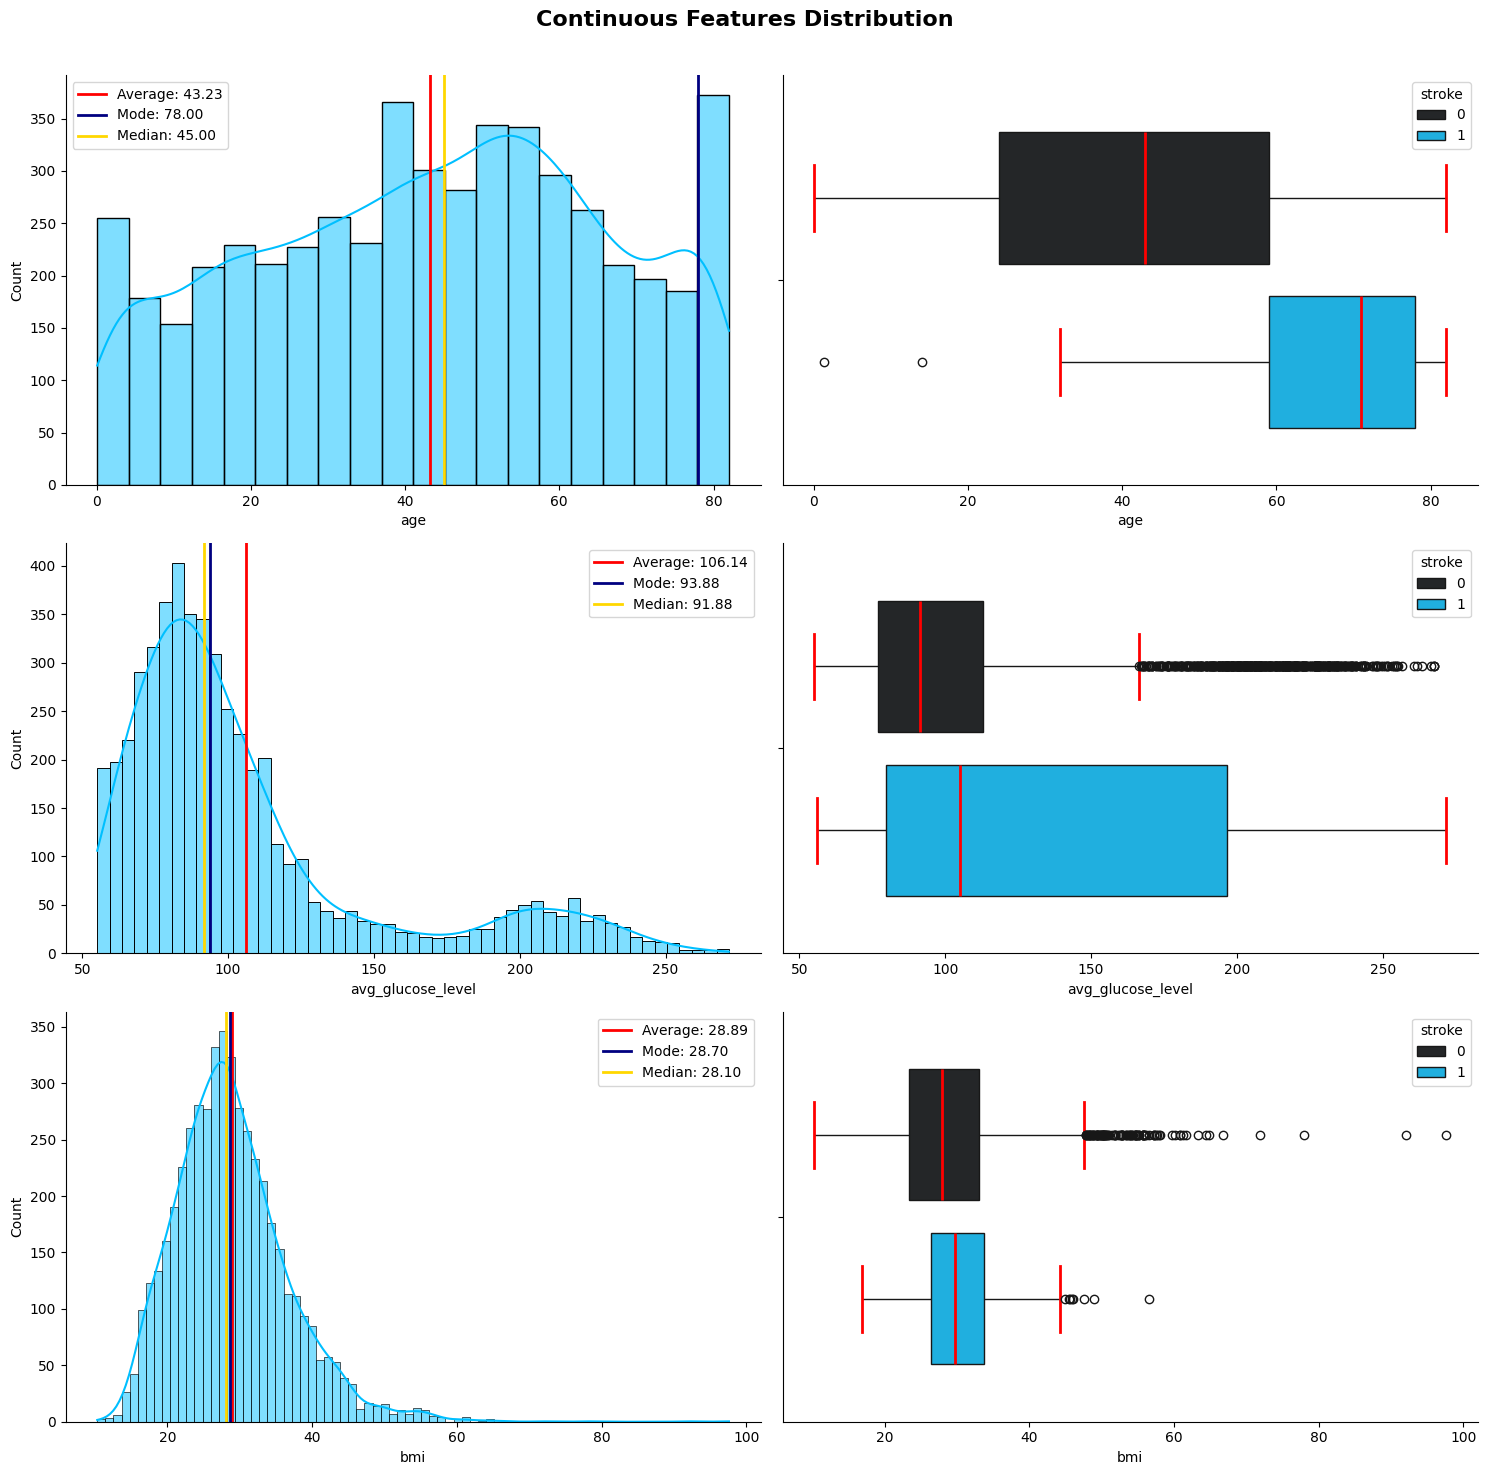

Outliers detected in the following columns:

avg_glucose_level: 627 outliers
bmi: 110 outliers


age                 -0.137430
avg_glucose_level    1.572815
bmi                  1.055063
dtype: float64

In [12]:
df.loc[:, binary_features] = df[binary_features].apply(
    lambda x: x.astype("category").cat.codes
)

continuous_distribution_plot(df, numerical_features, 'stroke')
outliers_iqr(df[numerical_features])
df[numerical_features].skew()

After checking the distribution of numerical features, we observe that some of them contain outliers:
- `avg_glucose_level`: **627** outliers
- `bmi`: **110** outliers

At this stage, we will **leave these outliers**, since removing outliers without proper domain expertise could risk losing valuable information. In medical field, outliers may even indicate rare or critical patient cases.

We also observe skenews in the distribution:
- `age`: slightly left-skewed **-0.137430**
- `avg_glucose_level`: strongly right-skewed **1.572815**
- `bmi`: moderate right-skewed **1.054698**

To address this, we will apply a `log` transformation before model evaluation.

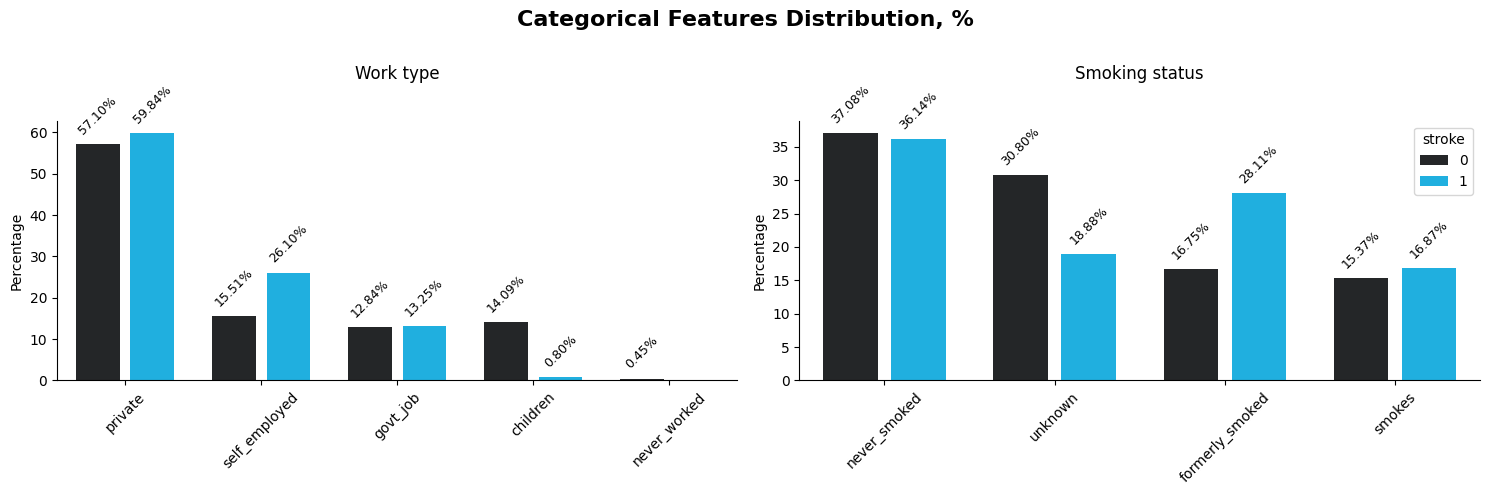

In [13]:
categorical_distribution_plot(df, categorical_features, 'stroke')

After checking the distribution of categorical features grouped by stroke cases, we oserve the following:

1. **Work type**
- Patients working in the **private sector** show highest percentage of stroke cases (`59.84%`).
- Smaller percentage of stroke cases are observed among **self employed** and **govorment job** categories.
- There almost no stroke cases in **Children** and **never worked** categories.

2. **Smoking status**
- Surprisingly, patiens who reported **never smoking** show the highest percentages of stroke cases, but since there are about `~37%` of the dataset falls into this group (following with **unknown** `~30%` since it does not represent an actual smoking category), this should be interpreted with causion, because it has biggest porcion of data.
- Patients who **formerly smoked** or **currently smoke** show lower percentages of stroke cases.

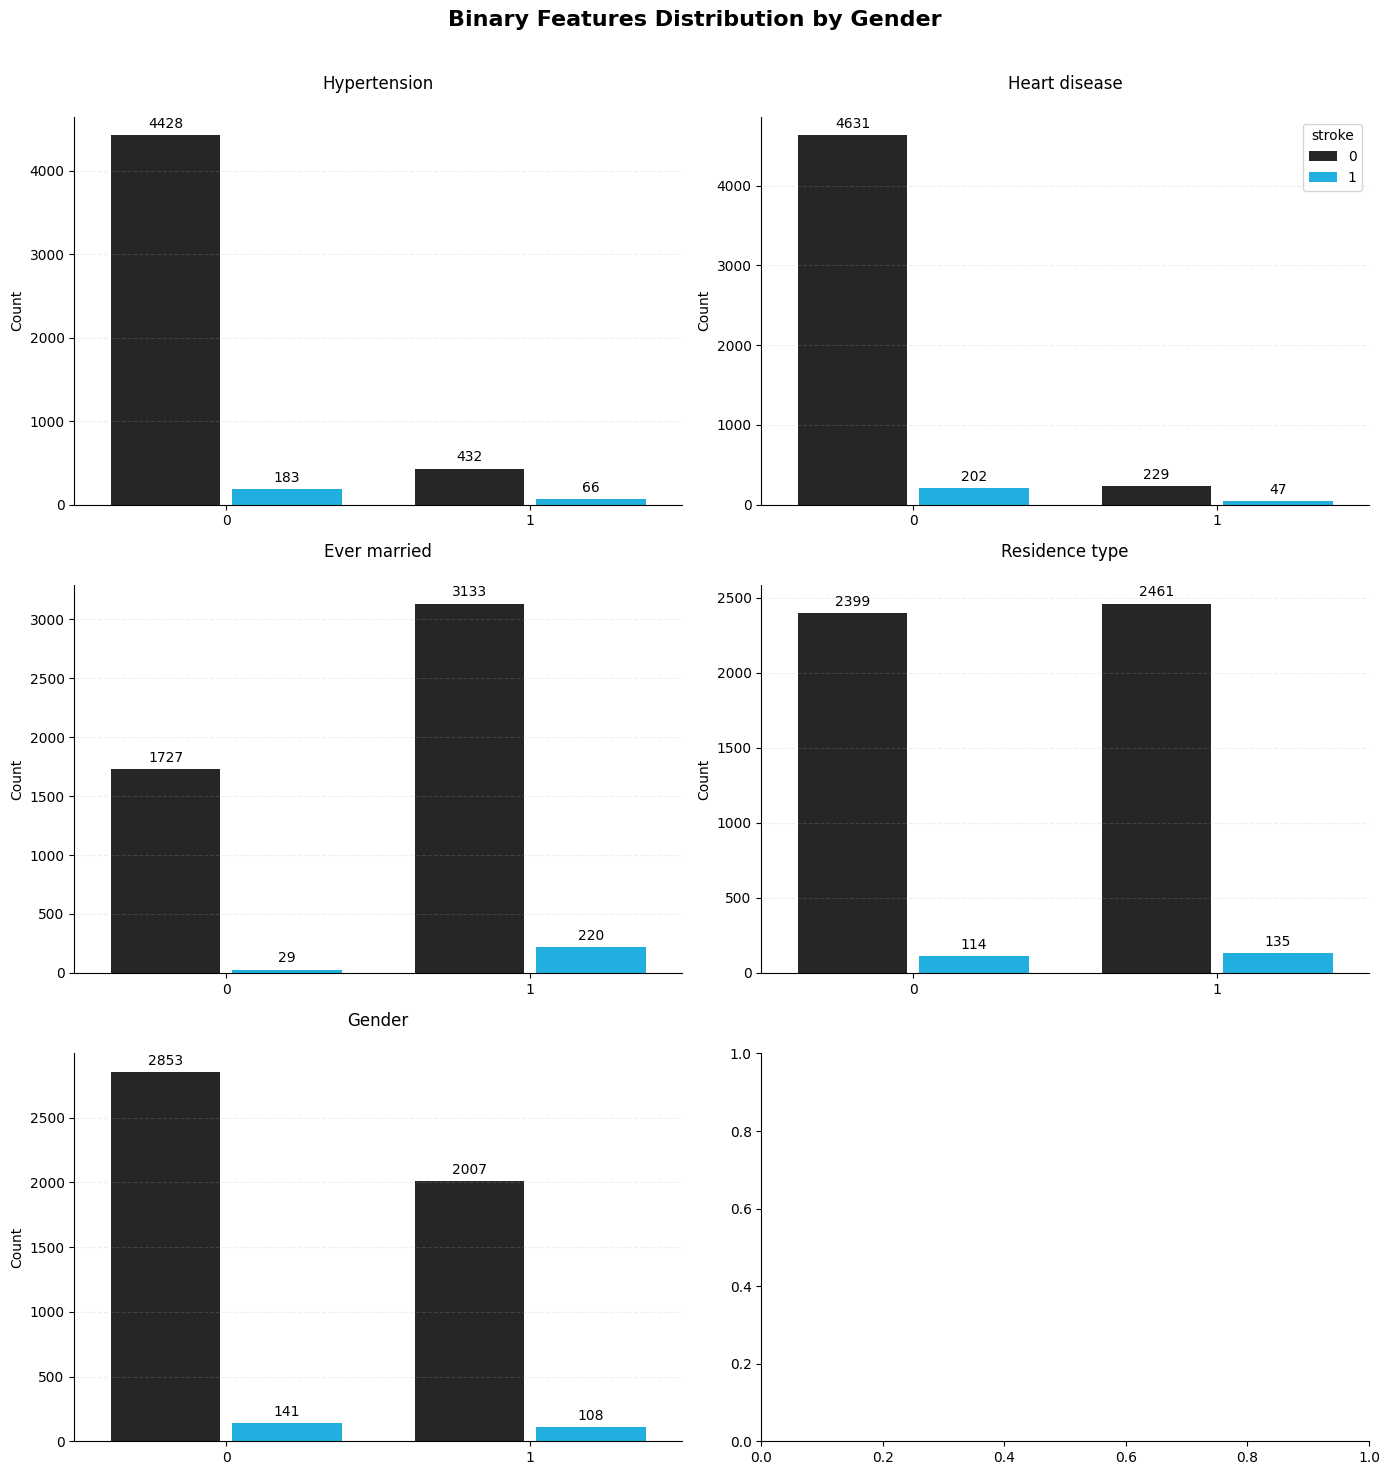

In [14]:
binary_distribution_plot(df, binary_features, 'stroke')

After checking the distribution of binary features grouped by stroke cases, we oserve the following:

1. **Hypertension**
- Most of the patients do not have `hypertension`.
- Stroke cases are hogher among patients with hypertensions.

2. **Heart disease**
- The majority of patients do not have `heart disease`.
- Patietns with heart disease have a higher proportion of stroke `1:5 (~20%)`

3. **Married status**
- A large share of patients are `married`.
- Stroke cases are more `frequent among married patients`, but this could may reflect the fact that married patients tend to be `older`.

4. **Residence type**
- Stroke and non-stroke cases are `evenly distributed` between urban and rural residence types.
- `No strong relationships` between residence type and stroce cases is visible.

5. **Gender**
- Stroke cases are e`venly distributed and relatively similar`.
- Female patients show a slightly higher count of stroke cases, but since there are `more females overall in the dataset`, this needs careful interpretation.

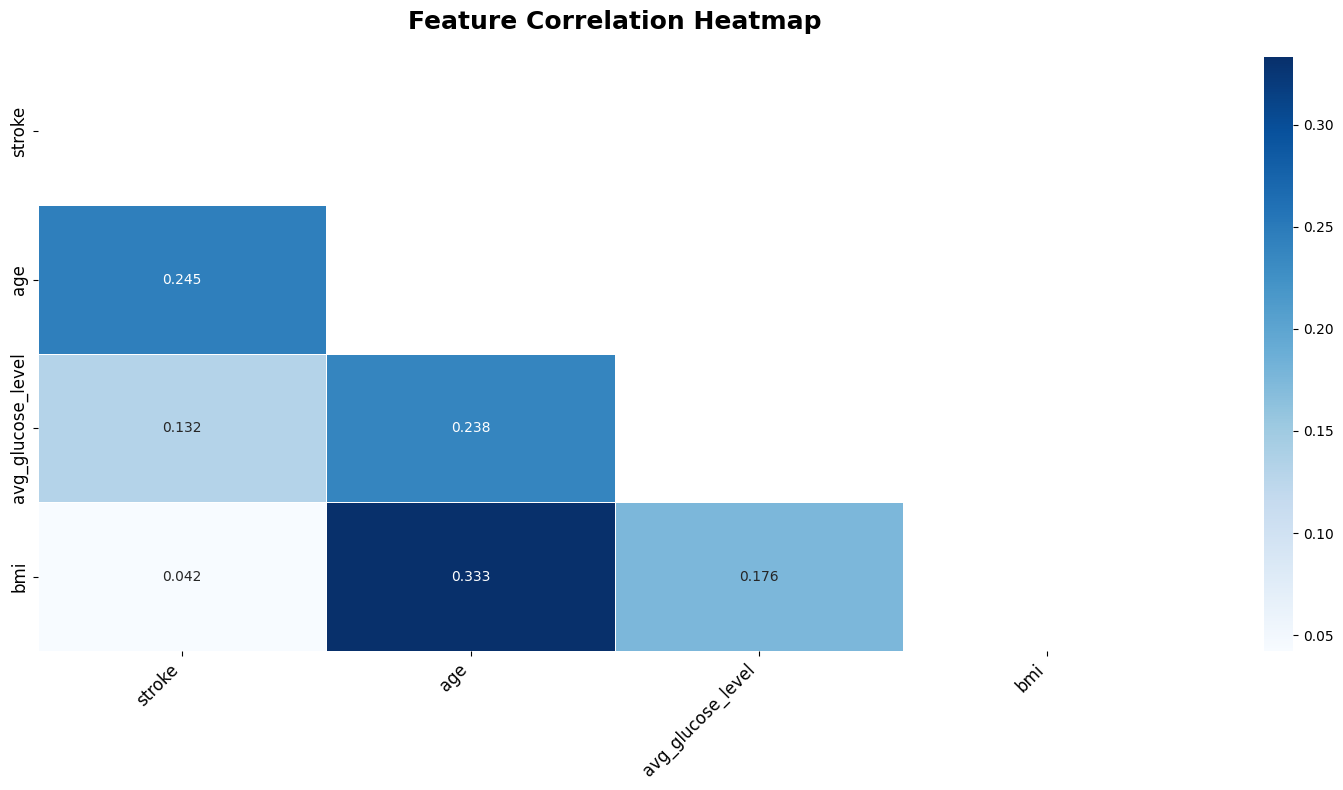

In [15]:
continuous_features_target = ["stroke", "age", "avg_glucose_level", "bmi"]

feature_correlation_plot(df[continuous_features_target])

From correlation matrix we can observe:

1. **Stroke vs features**:
- `Age`: shows strongest correlation. It suggest that risk to have a stroke increases with age.
- `Average glucose level`: has weak correlation with target veriable.
- `BMI`: has no correlation.

2. **Between features**:
- `Age vs BMI`: shows strongest correlation. It suggest that BMI tend to increas with age.
- `Age vs Average glucose level`: shows weaker correlation.
- `BMI vs Average glucose level`: shows small correlation.

`None of the features are strongly correlated with target veriable`, indicating that stroke will likely depend on multiple signals rather a single strong predictor. `Age is the most influencial feature`, aligning with medical expectations. 

### **Statistical inference for `Stroke Risk` dataset**

Since only **bmi** column has missing data (**3.93%**), for EDA part we applied temporary handling (`median imputation`) for statistical tests such as `A/B testing` and `confidence intervals`.

In [16]:
median_bmi = df.groupby(['age', 'work_type'])['bmi'].transform('median')
df['bmi_filled'] = df['bmi'].fillna(median_bmi).round(1)

Next, we will examine the relationships between each feature and target variable `stroke`. This quick analysis will show which features might influence or potentially contribute to stroke risk. 

For this analysis we will use **Chi-Square** test. The **Chi-Square** test is a statistical test used to determine if there is a significant association between two categorical variables. In our case, we will use it to assess the relationship between various categorical features and the target variable (`stroke`).

- **H₀ (Null Hypothesis): There is no association between the categorical feature and the target variable.**
- **H₁ (Alternative Hypothesis): There is an association between the categorical feature and the target variable.**

In [17]:
features_to_test = [
    "gender", 
    "hypertension", 
    "heart_disease", 
    "ever_married", 
    "residence_type", 
    "work_type", 
    "smoking_status"
]

chi_square_test(df, features_to_test, 'stroke')

,Feature,Chi-Square statistic,p-value,Significant (α=0.05)
2,heart_disease,90.2294,0.0000,Yes
1,hypertension,81.5731,0.0000,Yes
3,ever_married,58.8678,0.0000,Yes
5,work_type,49.1591,0.0000,Yes
6,smoking_status,29.2257,0.0000,Yes
4,residence_type,1.0750,0.2998,No
0,gender,0.3400,0.5598,No


**Heart disease, Hypertension**
- **H₁ (Alternative Hypothesis)**: there is an association between the `heart_disease`, `hypertension` features and the target variable `stroke`.
- **Conclusion**: patients with heart disease and hypertension are more likly to expriance a stroke. These two factors are well known in medicine and align with medical expectations.


**Married status, Working type, Smoking status**
- **H₁ (Alternative Hypothesis)**: there is an association between the `ever_married`, `work_type`, `smoking_status`, `smoking_unknown` feature and the target variable `stroke`.
- **Conclusion**: social and demographic features such as marital status, work type, and smoking status may act as potential indicators of stroke risk. Interestingly, the smoking_unknown feature also shows significant association — ignoring this group may lead to losing potentially important information.

**Residence type, Gender**
- **H₀ (Null Hypothesis)**: there is no association between the `residence_type`, `gender` features and the target variable `stroke`. 
- **Conclusion**: residence type (urban vs. rural) does not significantly affect stroke risk. Gender also does not appear to be a determining factor in predicting stroke occurrence.

Based on `Central Limit Theory (CLT)`, we will use `t_test` to compare the means of numerical features between patients who experience a stroke and who did not:

**H₀ (Null Hypothesis): there is no significant difference in the mean values between patients with stroke cases and those without.**

**H₁ (Alternative Hypothesis): there is a significant difference in the mean values between patients with stroke cases and those without.**

In [18]:
numerical_features = ['age', 'avg_glucose_level', 'bmi_filled']

t_test(df, numerical_features, 'stroke')

,Feature,t-stat,p-value,Significant (α=0.05)
0,age,-29.6819,0.0000,Yes
1,avg_glucose_level,-6.9844,0.0000,Yes
2,bmi_filled,-3.6155,0.0004,Yes


The t-test results show significant differences in mean values between patients with and without stroke (`H₁: Alternative Hypothesis accepted`):

- `Age`: stroke patients are, on average, significantly older. This confirms that age is a very important factor, which aligns with well-established medical knowledge.

- `Average glucose level`: stroke patients tend to have significantly higher average glucose levels compared to non-stroke patients.

- `BMI`: the effect is weaker compared to age and glucose, but patients who experienced a stroke still have a higher average BMI.


In [19]:
confidence_interval = confidence_interval_t(df, numerical_features, 'stroke')
confidence_interval

,Feature,Group,Mean,CI Lower,CI Upper
0,age,0,41.974831,41.347918,42.601745
1,age,1,67.728193,66.139597,69.316788
2,avg_glucose_level,0,104.787584,103.554539,106.020629
3,avg_glucose_level,1,132.544739,124.815952,140.273526
4,bmi_filled,0,28.828251,28.608496,29.048006
5,bmi_filled,1,30.240161,29.503380,30.976941


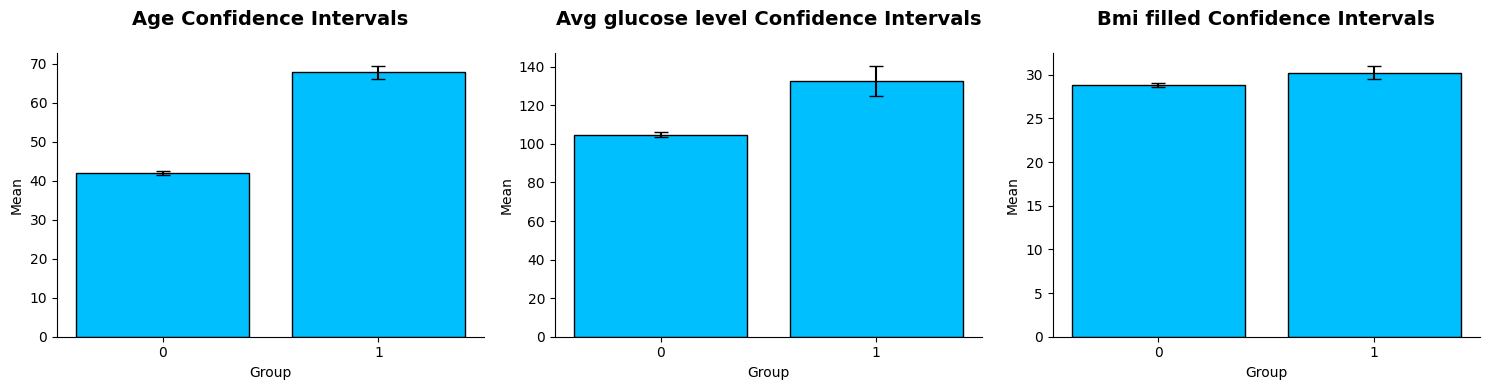

In [20]:
plot_confidence_intervals(confidence_interval)

df = df.drop(columns=['bmi_filled'])

Based on **95% confidence interval** results:

 - `Age`: patients without stroke have an average age of about 42 years `(95% CI: 41.3 – 42.6)`, while patients who experienced a stroke have an average age of about 68 years `(95% CI: 66.1 – 69.3)`.

- `Average Glucose Level`: patients without stroke have an average glucose level of about 105 `(95% CI: 103.6 – 106.0)`, while patients who experienced a stroke have an average glucose level of about 133 `(95% CI: 124.8 – 140.2)`.

- `BMI`: patients without stroke have an average BMI of about 28 `(95% CI: 28.6 – 29.0)`, while patients who experienced a stroke have an average BMI of about 30 `(95% CI: 29.4 – 30.97`).

### **Feature Engineering in `Stroke Risk` dataset**

Feature engeneering is crucial because it transforms raw data into a format that helps machine learning models perform better by improving accuracy, reducing overfitting, enhancing interpretability, and increasing computational efficiency. 

We will use `feauture creation`, `feature transformation` later in preprocessor and `feature scaling`.

In [ ]:
df["age_hypertension"] = df["age"] * df["hypertension"]
df["age_heart_disease"] = df["age"] * df["heart_disease"]
df["age_vs_glucose"] = df["avg_glucose_level"] / df["age"]
df["cardio_flag"] = ((df["hypertension"] == 1) | (df["heart_disease"] == 1)).astype(int)
df["critical_values"] = ((df["bmi"] >= 30) & (df["avg_glucose_level"] >= 124)).astype(int)
df["risk_score_weighted"] = df.apply(risk_score_weighted, axis=1)

In [22]:
df['age_group'] = pd.cut(df['age'], 
    bins = [-np.inf, 12, 19, 25, 35, 50, 65, np.inf],
    labels = ['child', 'teen', 'young_middle', 'young_adult', 'mid_adulthood', 'late_adulthood', 'senior']
)

df['bmi_group'] = pd.cut(df['bmi'],
    bins = [-np.inf, 18.5, 24.9, 29.9, 34.9, 39.39, np.inf],
    labels = ['underweight', 'healthy_weight', 'overweight', 'obesity_I', 'obesity_II', 'obesity_III']
)

df['avg_glucose_level_group'] = pd.cut(df['avg_glucose_level'],
    bins = [-np.inf, 70, 100, 125, np.inf],
    labels = ['lower_than_normal', 'normal', 'pre_diabetic', 'diabetic_condition']
)

df["risk_group"] = pd.cut(df["risk_score_weighted"], 
    bins=[-1, 3, 7, 10, 12], 
    labels=["low", "medium", "high", "very_high"])

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,...,age_hypertension,age_heart_disease,age_vs_glucose,cardio_flag,critical_values,risk_score_weighted,age_group,bmi_group,avg_glucose_level_group,risk_group
0,1,67.0,0,1,1,private,1,228.69,36.6,formerly_smoked,...,0.0,67.0,3.413284,1,1,10,senior,obesity_II,diabetic_condition,high
1,0,61.0,0,0,1,self_employed,0,202.21,NaN,never_smoked,...,0.0,0.0,3.314918,0,0,3,late_adulthood,NaN,diabetic_condition,low
2,1,80.0,0,1,1,private,0,105.92,32.5,never_smoked,...,0.0,80.0,1.324000,1,0,7,senior,obesity_I,pre_diabetic,medium
3,0,49.0,0,0,1,private,1,171.23,34.4,smokes,...,0.0,0.0,3.494490,0,1,4,mid_adulthood,obesity_I,diabetic_condition,medium
4,0,79.0,1,0,1,self_employed,0,174.12,24.0,never_smoked,...,79.0,0.0,2.204051,1,0,8,senior,healthy_weight,diabetic_condition,high


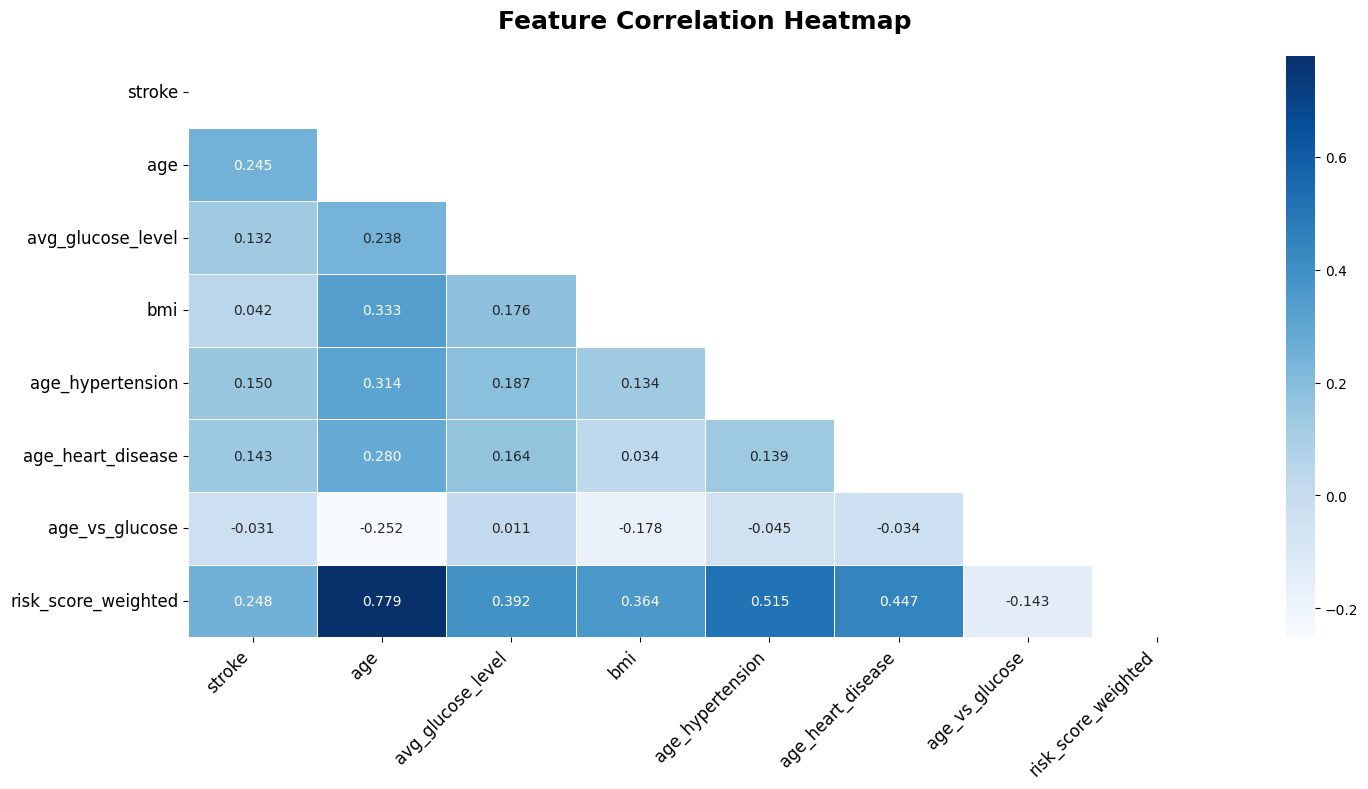

In [23]:
features_corr = [
    "stroke", "age", "avg_glucose_level", "bmi","age_hypertension", 
    "age_heart_disease", "age_vs_glucose", 'risk_score_weighted',
]

feature_correlation_plot(df[features_corr])

In [24]:
numeric_columns = df.loc[:, df.select_dtypes(include="number").columns.difference(
    df.columns[(df == 0).any()]
)].skew()

skewed_columns = numeric_columns[numeric_columns.abs() > 1].sort_values(ascending=False)

print("Skewed Columns:")
print(skewed_columns)

Skewed Columns:
age_vs_glucose       25.934965
avg_glucose_level     1.572815
bmi                   1.055063
dtype: float64


In the feature engineering stage, we:

- Created new features by `combining existing ones`.
- Identified categorical features that will later be transformed using `one-hot encoding`.
- Detected skewed data distributions and planned `logarithmic transformations`.

This strategy should help improve model performance in the later stages of the project.

### **ML models: predicting `stroke risk`**

To prepare our dataset for maschne learning, we will split the data into features and target veriable **Target veriable** - `stroke`, which indicating whether patient experienced stroke or not. 

In [25]:
numerical_features = ["age", "age_heart_disease", "age_hypertension"]
binary_features = ["critical_values", "cardio_flag",
                      'hypertension', 'heart_disease', 
                      'ever_married', "gender", 'residence_type']
ordinal_features = ['age_group', 'bmi_group', 'avg_glucose_level_group', "risk_score_weighted", "risk_group"]
categorical_features = ["work_type", "smoking_status"]
log_features = ["avg_glucose_level", "bmi", "age_vs_glucose"]


X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

imputer = KNNImputer(n_neighbors=5)

X_train[log_features] = imputer.fit_transform(X_train[log_features])
X_test[log_features] = imputer.transform(X_test[log_features])

print(f"Number of samples in testing: {X_test.shape[0]} => "
      f"{X_test.shape[0] / X.shape[0] * 100:.2f}% of the original dataset")
print(f"Number of samples in training: {X_train.shape[0]} => "
      f"{X_train.shape[0] / X.shape[0] * 100:.2f}% of the original dataset")

Number of samples in testing: 1533 => 30.01% of the original dataset
Number of samples in training: 3576 => 69.99% of the original dataset


In [26]:
print(f"Target variable distribution in full dataset:\n{y.value_counts(normalize=True)}")
print(f"\nTarget variable distribution in training dataset:\n{y_train.value_counts(normalize=True)}") 
print(f"\nTarget variable distribution in testing dataset:\n{y_test.value_counts(normalize=True)}")

Target variable distribution in full dataset:
stroke
0    0.951262
1    0.048738
Name: proportion, dtype: float64

Target variable distribution in training dataset:
stroke
0    0.951342
1    0.048658
Name: proportion, dtype: float64

Target variable distribution in testing dataset:
stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


These proportions demonstrates that `stratified sampling` was effective, as the class ditributions in the training data and testing sets closely shows the distribution in the full dataset. This ensures evaluation and avoids bias to class imbalance. 

Before the modeling we define separate preprocesing steps for **skewed**, **numerical**, **binary**, **ordinal** and **categorical** features.

**Mashine learning models to evaluate**:

- `Logistic Regression`: linear classifier often used for binary classification problems.
- `XGBoost Classifier`: powerful gradient boosting algorithm optimized for speed and performance, often used in structured/tabular data tasks.
- `LightGBM Classifier`: gradient boosting framework that uses tree-based learning, designed to be faster and more memory-efficient than XGBoost.
- `CatBoost Classifier`: gradient boosting algorithm that handles categorical features automatically and helps reduce overfitting with built-in regularization.

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("log", Pipeline(steps=[
            ("log_transform", FunctionTransformer(np.log1p, validate=True))
        ]), log_features),
        ("numerical", 
         StandardScaler(), numerical_features),
        ("binary", "passthrough", binary_features),
        ("ordinal",
        OrdinalEncoder(
            categories=[
        ['child_or_teen', 'young_middle', 'young_adult', 'mid_adulthood', 'late_adulthood', 'senior'],
        ['underweight', 'healthy_weight', 'overweight', 'obesity_I', 'obesity_II', 'obesity_III'],
        ['lower_than_normal', 'normal', 'pre_diabetic', 'diabetic_condition'],
        list(range(0, 13)),
        ["low", "medium", "high", "very_high"]
        
    ],
            handle_unknown='use_encoded_value', 
            unknown_value=-1,
            dtype=int,
            ), ordinal_features),
        ("categorical", 
         OneHotEncoder(
            handle_unknown="ignore", 
            sparse_output=False), categorical_features)
    ],  
    verbose_feature_names_out=False
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count

print(f"Negative cases: {neg_count}, Positive cases: {pos_count}")
print(f"Class imbalance ratio (neg:pos) = {imbalance_ratio:.2f}:1")

models = {
    "LogisticRegression": LogisticRegression(
        random_state=42, class_weight="balanced", solver="saga", n_jobs=-1
    ),
    "XGBClassifier": XGBClassifier(
        random_state=42, scale_pos_weight=imbalance_ratio, tree_method="hist", n_jobs=-1
    ),
    "LGBMClassifier": LGBMClassifier(
        random_state=42, scale_pos_weight=imbalance_ratio, verbose=-1, n_jobs=-1
    ),
    "CatBoostClassifier": CatBoostClassifier(
        random_state=42, verbose=0, auto_class_weights="Balanced", loss_function="Logloss",
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

Negative cases: 3402, Positive cases: 174
Class imbalance ratio (neg:pos) = 19.55:1


These models will be trained and compared to identify the best performer for predicting stroke. To provide more reliable and unbiased performence estimates, especially when tarhet veriable is imbalanced we will use `5-fold stratidied cross -validation` metod.

We evaluate models by using the following metrics:

- `Precision`: the proportion of predicted stroke cases that were actual strokes (useful when false positives are costly.)

- `Recall`: the proportion of actual stroke cases correctly identified (important if missing a stroke is costly).

- `F1 Score`: balance between precision and recall.

- `PR AUC`: area under the Precision-Recall curve. Useful for imbalanced datasets, as it focuses on how well the model identifies the positive class.

In [28]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['precision', 'recall', 'f1', 'average_precision']
results = {}

for name, model in pipelines.items():
    scores = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)
    
    results[name] = {
        "Precision": f"{scores['test_precision'].mean():.3f}",
        "Recall": f"{scores['test_recall'].mean():.3f}",
        "F1 Score": f"{scores['test_f1'].mean():.3f}",
        "PR AUC": f"{scores['test_average_precision'].mean():.3f}",
        "Fit Time": f"{scores['fit_time'].mean():.2f} s"
    }
    

cv_results_df = pd.DataFrame(results).T
cv_results_df = cv_results_df.sort_values(by="Recall", ascending=False)
cv_results_df

,Precision,Recall,F1 Score,PR AUC,Fit Time
LogisticRegression,0.164,0.661,0.219,0.199,0.08 s
CatBoostClassifier,0.163,0.258,0.199,0.177,3.87 s
LGBMClassifier,0.145,0.155,0.150,0.161,0.26 s
XGBClassifier,0.194,0.149,0.168,0.188,0.13 s


These results provide a strong foundation for further model selection. Now we can apply hyperparameter tuning procces to improve models performence and better understand each model.

To improve performence of our baseline, we define a search for each models key hyperparameters. These configurations will be used in randomized search during cross-validation to identify the best model settings.

For best model performance, we will use `RandomizedSearchCV` to search for the best hyperparameters. Since our dataset is imbalanced and the positive class represents the critical cases we aim we are using scoring `average_precision` because it will handle inbalance and will keep both recall and precision.

In [29]:
best_models = {}
results = []

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=202)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in pipelines.items():
    model_search = RandomizedSearchCV(
        model,
        param_distributions[name],
        n_iter=50,
        n_jobs=-1,
        cv=inner_cv,
        random_state=42,
        scoring='average_precision',
    )
    
    model_search.fit(X_train, y_train)
    best_model = model_search.best_estimator_
    best_models[name] = best_model

    y_pred_proba = cross_val_predict(best_model, X_train, y_train, cv=outer_cv, method="predict_proba")[:, 1]
    y_pred_oof = (y_pred_proba >= 0.5).astype(int)

    recall = recall_score(y_train, y_pred_oof)
    precision = precision_score(y_train, y_pred_oof)
    f1 = f1_score(y_train, y_pred_oof)
    acc = accuracy_score(y_train, y_pred_oof)
    roc_auc = roc_auc_score(y_train, y_pred_proba)
    average_precision = average_precision_score(y_train, y_pred_proba)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "PR AUC": average_precision,
        "Fit Time": f"{model_search.refit_time_:.2f} s",
    })
    
    print(f"\nBest parameters for {name}:")
    print(model_search.best_params_)
    print(f"Best model fit time: {model_search.refit_time_:.2f} seconds")


Best parameters for LogisticRegression:
{'classifier__C': np.float64(0.0745934328572655), 'classifier__l1_ratio': np.float64(0.9507143064099162), 'classifier__max_iter': 2130, 'classifier__multi_class': 'auto', 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'classifier__tol': np.float64(0.007792297153882997)}
Best model fit time: 5.59 seconds

Best parameters for XGBClassifier:
{'classifier__colsample_bytree': np.float64(0.9010984903770198), 'classifier__gamma': np.float64(0.3727532183988541), 'classifier__grow_policy': 'depthwise', 'classifier__learning_rate': np.float64(0.0018629639119246224), 'classifier__max_depth': 3, 'classifier__min_child_weight': 4, 'classifier__n_estimators': 947, 'classifier__reg_alpha': np.float64(0.00010388823104027947), 'classifier__reg_lambda': np.float64(0.02795015916508337), 'classifier__subsample': np.float64(0.8534286719238086)}
Best model fit time: 1.12 seconds

Best parameters for LGBMClassifier:
{'classifier__bagging_freq': 0, 'classif

**Lets look to `confusion matrices.`:**

| Term                    | Meaning                                                                       |
| ----------------------- | ----------------------------------------------------------------------------- |
| **True Positive (TP)**  | The model predicted **stroke**, and the patient actually **had a stroke**.    |
| **False Positive (FP)** | The model predicted **stroke**, but the patient actually **did not**.         |
| **True Negative (TN)**  | The model predicted **no stroke**, and the patient actually **did not**.      |
| **False Negative (FN)** | The model predicted **no stroke**, but the patient actually **had a stroke**. |


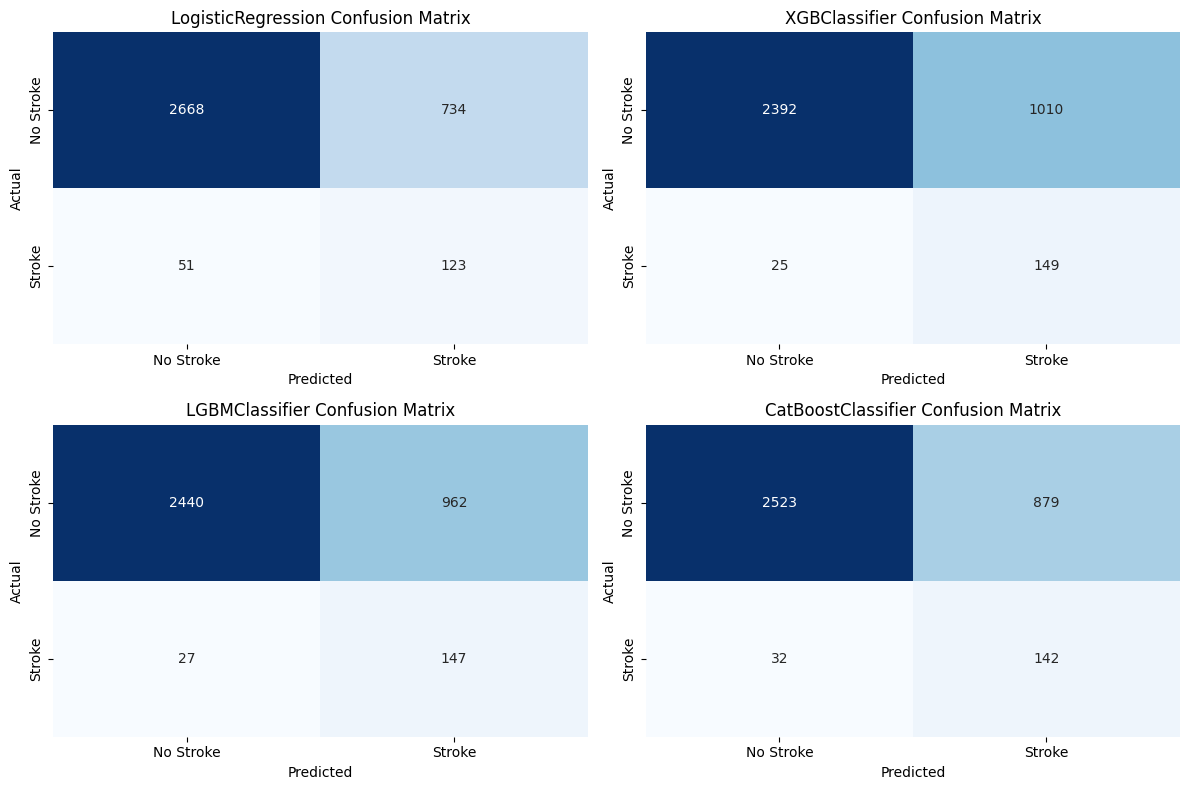

,Model,Precision,Recall,F1 Score,PR AUC,Fit Time
1,XGBClassifier,0.118399,0.798851,0.206231,0.196433,1.12 s
2,LGBMClassifier,0.122575,0.798851,0.212538,0.225788,0.29 s
3,CatBoostClassifier,0.128655,0.758621,0.220000,0.165909,1.27 s
0,LogisticRegression,0.150198,0.655172,0.244373,0.151721,5.59 s


In [30]:
plot_confusion_matrix(best_models, X_train, y_train, cv=skf)

results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False)

Based on the metrics `LightGBM Classifier` is currently the best canditate overall it demonstrated strong performance with the best balance across key metrics. 

| Model                   | True Negatives (TN) | False Positives (FP) | False Negatives (FN) | True Positives (TP) |
| ----------------------- | ------------------- | -------------------- | -------------------- | ------------------- |
| **Logistic Regression** | 2668                | 734                  | 51                   | 123                 |
| **XGBoost Classifier**  | 2392                | 1010                 | 25                   | 149                 |
| **LightGBM Classifier** | 2440                | 962                  | 27                   | 147                 |
| **CatBoost Classifier** | 2523                | 879                  | 32                   | 142                 |


**Model Selection**

`Based on the metrics:` **LightGBM Classifier** has the recall (0.799), precision (0.123), F1 score (0.213), PR AUC(0.226). Althought its precision is no the highest, it maintains a good balance. The confusion matrix shows that **LightGBM Classifier** provides the good performance in predicting true positives and reducing false negatives, which is our main focus in this problem.

`Conclusion:` we choose **LightGBM Classifier** for deployment as it offers best overall performence on key metrics. For our problem, we hypotheticly set the decision treshold to `8% precision`.

Best threshold: 0.11, when precision >= 0.08


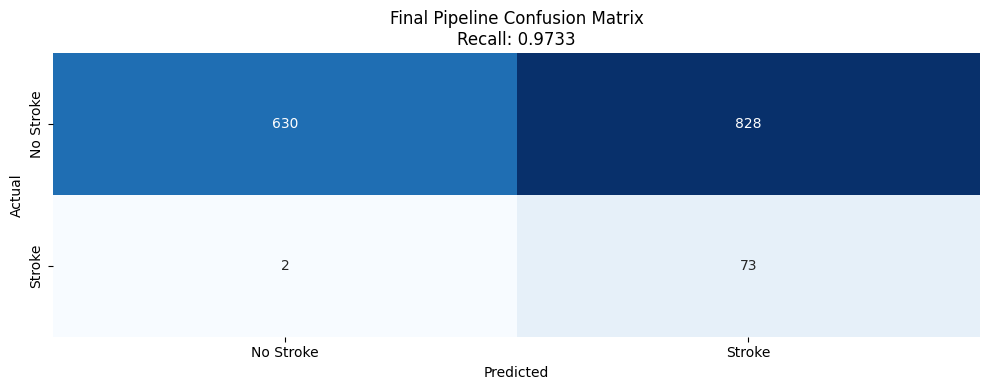

,Precision,Recall,F1 Score,PR AUC
Model,,,,
LGBMClassifier,0.081021,0.973333,0.14959,0.210058


In [31]:
best_model = best_models["LGBMClassifier"]
best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)

min_precision = 0.08
best_t = None
best_recall = 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    if precision >= min_precision and recall > best_recall:
        best_recall = recall
        best_t = t

print(f"Best threshold: {best_t:.2f}, when precision >= {min_precision}")

y_pred_custom = (y_proba >= best_t).astype(int)

results = {
    "Model": best_model.named_steps['classifier'].__class__.__name__,
    "Precision": precision_score(y_test, y_pred_custom),
    "Recall": recall_score(y_test, y_pred_custom),
    "F1 Score": f1_score(y_test, y_pred_custom),
    "PR AUC": average_precision_score(y_test, y_proba)
}

final_confusion_matrix(best_model, y_test, y_pred_custom)

final_results = pd.DataFrame([results]).set_index("Model")
final_results

With the precision set to `8%`, we achieved **strong recall** score, meaning that `~97%` of actual stroke cases (**true positives**) are `correctly idendified`, while **false negatives** remain low. However, this come with a high number of **false positives**. We could reduce this impact by adding additional steps, such as:

- `A double-cheking system` (e.g., medical staff review flagged cases)

- `Using the model's risk score` to prioritize the most likely cases

- Implementing a `secondary questionnaire` or `screening tool` to filter out unlikely cases before escalation.

Now we will check each feature importance on models performence:

| Action                      | Interpretation                                                             |
| --------------------------- | -------------------------------------------------------------------------- |
| **Keep and prioritize**     | High importance (e.g., > 0.03) - very useful                               |
| **Review carefully**        | Low importance (0.01–0.03) — may or may not be useful                      |
| **Drop or engineer better** | Negative or near-zero importance — probably confusing the model            |

In [32]:
permutation_results = permutation_importance(
    best_model, 
    X_test, 
    y_test, 
    n_repeats=50, 
    scoring="average_precision",
    n_jobs=-1,
    random_state=42)

for i in permutation_results.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]}: {permutation_results.importances_mean[i]:.4f}")

age: 0.1140
bmi_group: 0.0175
age_group: 0.0037
age_hypertension: 0.0015
age_vs_glucose: 0.0015
risk_score_weighted: 0.0007
ever_married: 0.0000
gender: 0.0000
hypertension: 0.0000
heart_disease: 0.0000
age_heart_disease: 0.0000
critical_values: 0.0000
residence_type: 0.0000
smoking_status: -0.0002
avg_glucose_level_group: -0.0002
avg_glucose_level: -0.0009
risk_group: -0.0014
cardio_flag: -0.0015
work_type: -0.0022
bmi: -0.0057


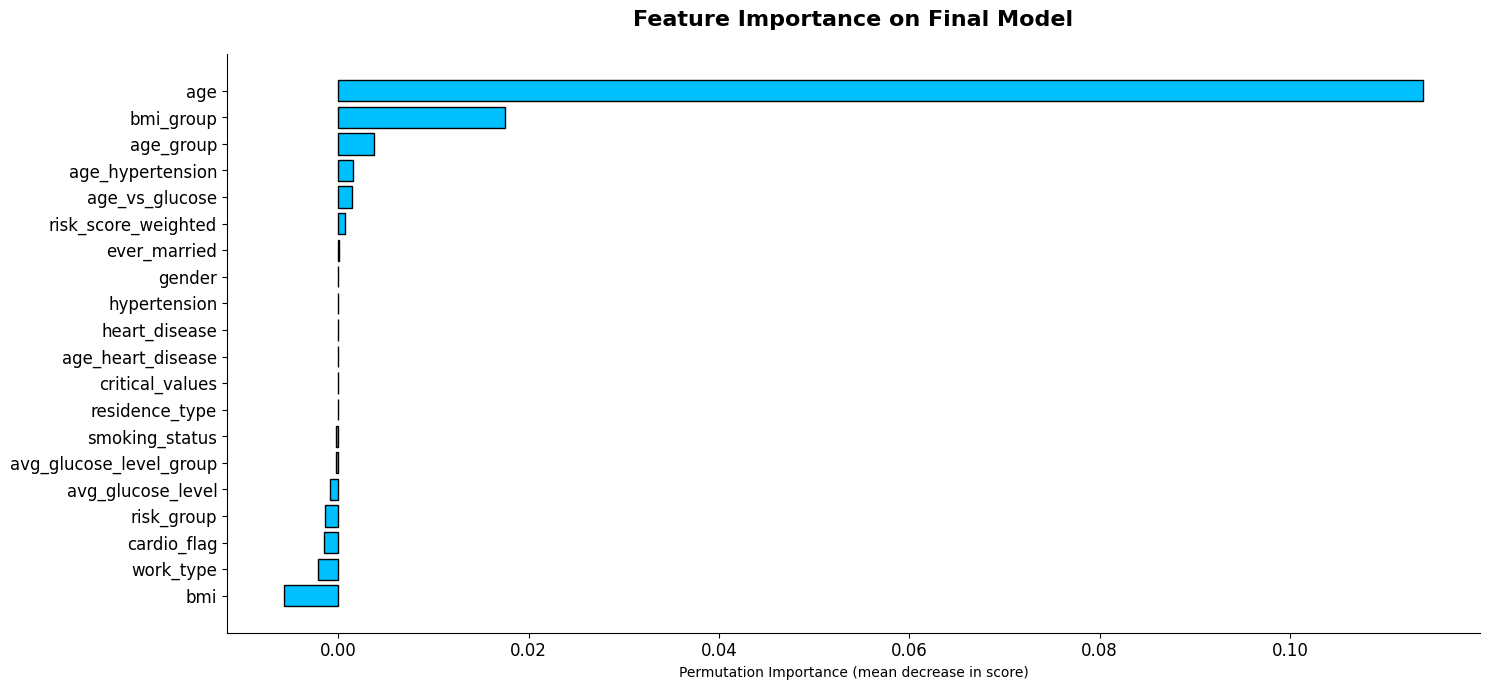

In [33]:
importances = permutation_results.importances_mean

plot_permutation_importance(X_test, importances)

After applying **permutation importnace** in the best model, we observed how permuting each feature affects its correlation with the target and model's statistical performence.

**14 features** showed negative or non-zero importance. Thus suggest that this feature may not provide meaningful predictive value.

Before re-launching the model, it is importnat to infor stakeholders about these findings and cosider to gather more domain knowledge to verify ther imporance. In theory, dropping them could simplify the model and potentially improve efficency.

Now we will combine the strengts of multiple individual models to `produce more accurate and robust predictions`.The key value of ensemble models lies in their reduced variance, bias, or both, depending on the strategy.

Best threshold: 0.13, when precision >= 0.08


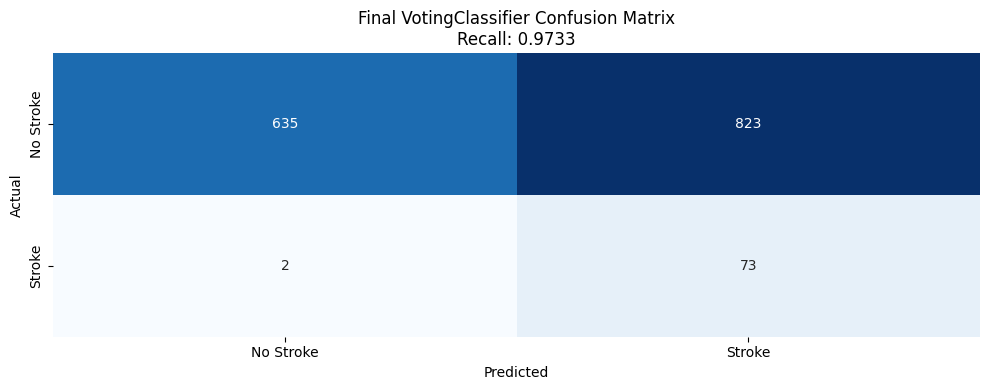

,Precision,Recall,F1 Score,PR AUC
Model,,,,
LGBMClassifier,0.081021,0.973333,0.14959,0.210058
LogisticRegression+CatBoostClassifier+LGBMClassifier,0.081473,0.973333,0.15036,0.227196


In [34]:
ensemble_model = ["LogisticRegression", "CatBoostClassifier", "LGBMClassifier"]

estimators = [(name, clone(best_models[name])) for name in ensemble_model]

voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    n_jobs=-1
)

min_precision = 0.08
best_t = None
best_recall = 0

voting_clf.fit(X_train, y_train)

y_proba_ensemble = voting_clf.predict_proba(X_test)[:, 1]

for t in thresholds:
    preds = (y_proba_ensemble >= t).astype(int)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    if precision >= min_precision and recall > best_recall:
        best_recall = recall
        best_t = t

print(f"Best threshold: {best_t:.2f}, when precision >= {min_precision}")

y_pred_custom = (y_proba_ensemble >= best_t).astype(int)

results_ensemble = {
    "Model": f"{'+'.join(ensemble_model)}",
    "Precision": precision_score(y_test, y_pred_custom),
    "Recall": recall_score(y_test, y_pred_custom),
    "F1 Score": f1_score(y_test, y_pred_custom),
    "PR AUC": average_precision_score(y_test, y_proba_ensemble)
}

final_confusion_matrix(voting_clf, y_test, y_pred_custom)

final_results_ensemble = pd.DataFrame([results, results_ensemble]).set_index("Model")
final_results_ensemble

After ensembling models and the precision set to `8%`, we achieved **strong recall** score, meaning that `~97%` of actual stroke cases (**true positives**) are `correctly idendified`, while **false negatives** remain low. However, this come with a high number of **false positives**. 

In [35]:
permutation_results = permutation_importance(
    voting_clf, 
    X_test, 
    y_test, 
    n_repeats=50, 
    scoring="average_precision",
    n_jobs=-1,
    random_state=42)

for i in permutation_results.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]}: {permutation_results.importances_mean[i]:.4f}")

age: 0.0978
age_group: 0.0399
bmi_group: 0.0307
age_hypertension: 0.0109
risk_score_weighted: 0.0100
risk_group: 0.0062
avg_glucose_level: 0.0041
age_vs_glucose: 0.0024
avg_glucose_level_group: 0.0023
cardio_flag: 0.0021
heart_disease: 0.0016
age_heart_disease: 0.0011
work_type: 0.0006
residence_type: 0.0002
hypertension: -0.0003
critical_values: -0.0003
bmi: -0.0003
ever_married: -0.0011
gender: -0.0022
smoking_status: -0.0030


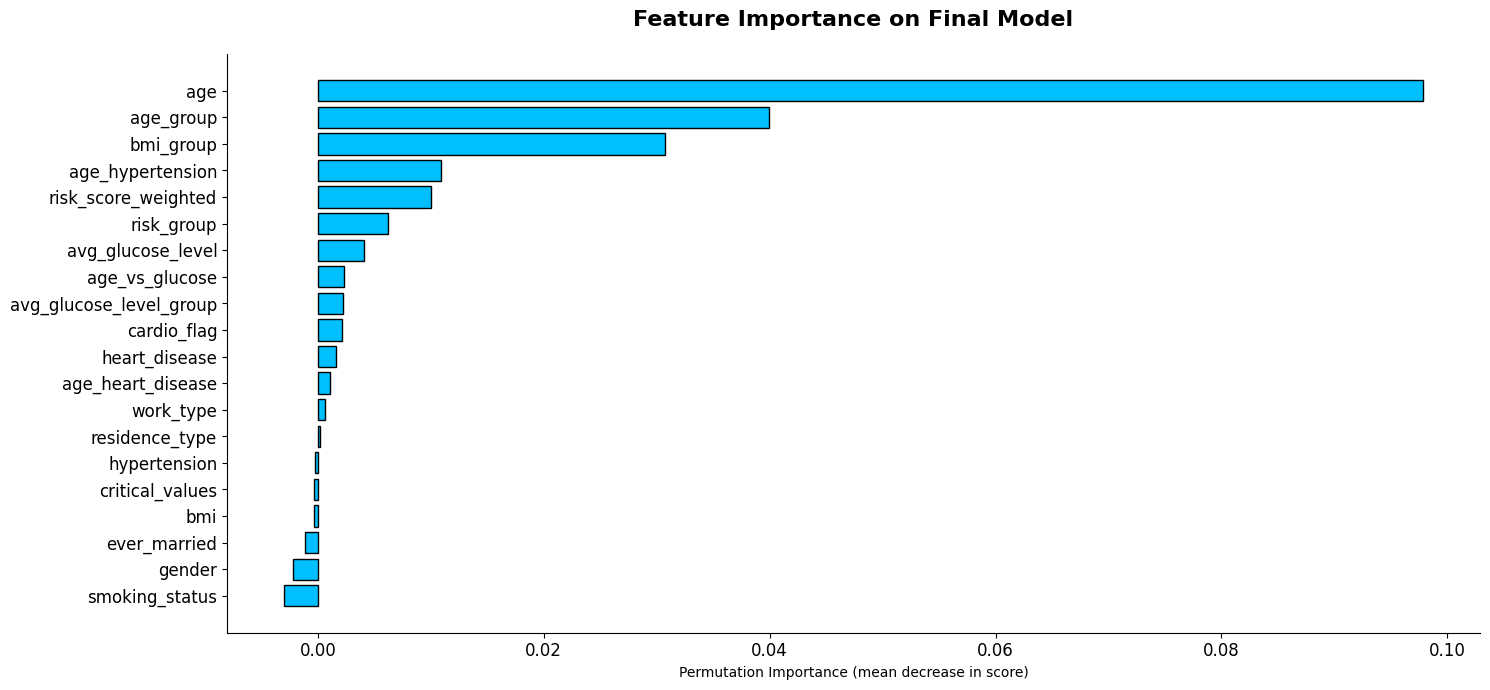

In [36]:
importances = permutation_results.importances_mean

plot_permutation_importance(X_test, importances)

In [37]:
save_folder = "modelAPI"
os.makedirs(save_folder, exist_ok=True)
model_path = os.path.join(save_folder, 'stroke_risk_model.pkl')
joblib.dump(voting_clf, model_path)

print(f"Model trained and saved as '{model_path}'")

Model trained and saved as 'modelAPI\stroke_risk_model.pkl'


Permutation importance (scored by Average Precision) flags 6 features with negative impact, indicating they add little value and may be not valuable. Our `LogisticRegression, CatBoostClassifier, LGBMClassifier` ensemble improves and relies on a wider set of informative features.

### **`Stroke Risk` prediction analysis results**

The analysis revealed important insights regarding the likelihood of a patient to experiance a stroke.

1. **LightGBM Classifier** has the recall (0.799), precision (0.123), F1 score (0.213), PR AUC(0.226). Althought its precision is no the highest, it maintains a good balance. The confusion matrix shows that **LightGBM Classifier** provides the good performance in predicting true positives and reducing false negatives, which is our main focus in this problem. 

After `ensembled models` we improved recall (0.973), F1 (0.150), PR AUC (0.227).

2. Key factor influencing stroke risk:
- `Patients age`

These factors are the `important predictors of stroke risk`. Need to be mensioned that heart disease and hypertention sntrongly align with medical expectations as major stroke risk factors. Social and lifstyle features(merital status, work type, smoking) also show notable associations. Meanwhile, residence type and gender do not significantly influence stroke risk.

3. 95% confidence interval results

| Feature              | No Stroke (95% CI)     | Stroke (95% CI)        |
|----------------------|-------------------------|-------------------------|
| Age (years)          | 42 (41.3 – 42.6)        | 68 (66.1 – 69.3)        |
| Avg. Glucose Level   | 105 (103.6 – 106.0)     | 133 (124.8 – 140.2)     |
| BMI                  | 28.8 (28.6 – 29.0)      | 30.2 (29.4 – 30.8)      |

- `Age`: stroke patients are, on average, significantly older. This confirms that age is a very important factor, which aligns with well-established medical knowledge.

- `Average glucose level`: stroke patients tend to have significantly higher average glucose levels compared to non-stroke patients.

- `BMI`: the effect is weaker compared to age and glucose, but patients who experienced a stroke still have a higher average BMI.

4. Final model performence:

| Model                  | Precision | Recall | F1 Score | PR AUC | Interpretation                                                                                                                                                                    |
| ---------------------- | --------- | ------ | -------- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **CatBoostClassifier** | 0.088     | 0.920  | 0.182    | 0.215  | Very high recall (catches most stroke cases) but **very low precision** (many false positives). PR AUC indicates the challenge of ranking positives in this imbalanced setting.   |
| **Ensembled model**    | 0.081     | 0.973  | 0.150    | 0.227  | **Improved model performence**, but precision remains **very low**, implying a high false-positive burden typical for recall-first operation on imbalanced data. |



**Final conclusion for The Johns Hopkins Hospital and recommendations**:

With the precision set to `8%`, we can achieve **strong recall** score, meaning that `~97%` of actual stroke cases (**true positives**) will be `correctly idendified`, while **false negatives** remain low. However, this come with a high number of **false positives**. We could reduce their impact by adding additional steps such as:

- `A double-cheking system` (e.g., medical staff review flagged cases)

- `Using the model's risk score` to prioritize the most likely cases

- Implementing a `secondary questionnaire` or `screening tool` to filter out unlikely cases before escalation.
